# Posterior estimation with NumPyro bridge

In [1]:
import astropy.units as u
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
import numpyro.distributions as dist
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time
from numpyro.infer import MCMC, NUTS, init_to_value

import nyx
from nyx import (
    Airglow,
    EffectiveApertureInstrument,
    Geometry,
    Moon,
    Observation,
    Scene,
    SingleScattering,
    Stars,
    ZodiacalLight,
    freeze_all,
    unfreeze,
)
from nyx.infer import init_values, scene_model

nyx.configure()

JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Building the model

In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 40) * u.nm,  # wavelength grid
    nside=32,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

hess_ct1 = EffectiveApertureInstrument.from_iactrace_table(geo, "CT1_aperture.npz")
hess_stereo = {"CT1": hess_ct1, "CT2": hess_ct1, "CT3": hess_ct1, "CT4": hess_ct1}
atmosphere = SingleScattering.from_hg_ozone(geo)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

In [3]:
location_ct1 = EarthLocation.from_geodetic(
    lon=16.50091 * u.deg,
    lat=-23.27153 * u.deg,
    height=1.835 * u.km,
)
location_ct2 = EarthLocation.from_geodetic(
    lon=16.50010 * u.deg,
    lat=-23.27075 * u.deg,
    height=1.835 * u.km,
)
location_ct3 = EarthLocation.from_geodetic(
    lon=16.49925 * u.deg,
    lat=-23.27151 * u.deg,
    height=1.835 * u.km,
)
location_ct4 = EarthLocation.from_geodetic(
    lon=16.50012 * u.deg,
    lat=-23.27232 * u.deg,
    height=1.835 * u.km,
)

times = Time("2021-01-12T21:12:16", scale="utc") + jnp.linspace(0, 30, 3) * 60 * u.s
target = SkyCoord(l=184 * u.deg, b=-6 * u.deg, frame="galactic")

observations = {
    "CT1": Observation(location_ct1, times, target, geo),
    "CT2": Observation(location_ct2, times, target, geo),
    "CT3": Observation(location_ct3, times, target, geo),
    "CT4": Observation(location_ct4, times, target, geo),
}

scene = Scene.build(hess_stereo, atmosphere, sources, observations)

Scene(instruments: CT1(3 obs), CT2(3 obs), CT3(3 obs), CT4(3 obs); sources: airglow, zodiacal, GaiaDR3, moon; atmosphere: SingleScattering; 3884 of 3884 parameter values free)

## Synthetic truth data
We changed aod_500, anstrom_exp, pointing shifts and instrument efficiency. We also add a 5% relative error.

In [11]:
rng = np.random.default_rng(44)
true_shifts = {
    name: np.deg2rad(rng.uniform(-0.05, 0.05, size=(scene.nobs[name], 2))) for name in scene
}

truth = scene.set_params(
    {f"instruments.{name}.shift": jnp.asarray(s) for name, s in true_shifts.items()}
    | {
        "atmosphere.components.Mie.aod_500": 0.15,
        "atmosphere.components.Mie.angstrom_exp": 1.3,
        "instruments.*.efficiency": 0.8,
    }
)

rel_error = 0.05
truth_images = {
    name: jnp.asarray(np.asarray(r) * rng.lognormal(0.0, rel_error, size=r.shape))
    for name, r in truth.render().items()
}

## Parameter freezing and priors

We freeze all parameters, then selectively unfreeze all parameters we want to sample.

In [12]:
model_scene = unfreeze(
    freeze_all(scene),
    "atmosphere.components.Mie.aod_500",
    "atmosphere.components.Mie.angstrom_exp",
    "instruments.*.shift",
    "instruments.*.rotation",
    "instruments.*.efficiency",
)

We define our priors using numpyro dists and then create a numpyro `scene_model`, with the likelihood containing a fittable sigma.

In [13]:
priors = {
    "atmosphere.components.Mie.aod_500": dist.Uniform(0.001, 2.0),
    "atmosphere.components.Mie.angstrom_exp": dist.Uniform(0.0, 2.5),
    "instruments.*.shift": dist.Uniform(-jnp.deg2rad(0.1), jnp.deg2rad(0.1)),
    "instruments.*.rotation": dist.Uniform(-jnp.deg2rad(1.0), jnp.deg2rad(1.0)),
    "instruments.*.efficiency": dist.Uniform(0.5, 2.0),
}


def nyx_model():
    sigma = numpyro.sample("rel_error", dist.HalfNormal(0.1))
    scene_model(
        model_scene,
        truth_images,
        priors,
        lambda predicted: dist.LogNormal(jnp.log(predicted), sigma),
    )()

## Running NUTS

`init_values` gives the current values of the model_scene, which enables us to start from a fit or other initialization.

In [14]:
kernel = NUTS(
    nyx_model,
    max_tree_depth=6,
    init_strategy=init_to_value(values=init_values(model_scene)),
    dense_mass=[
        (
            "atmosphere.components.Mie.aod_500",
            "atmosphere.components.Mie.angstrom_exp",
            *(f"instruments.{name}.efficiency" for name in scene),
            "rel_error",
        )
    ],
)

mcmc = MCMC(kernel, num_warmup=500, num_samples=2000, num_chains=1)
mcmc.run(jax.random.PRNGKey(0), extra_fields=("num_steps",))
mcmc.print_summary()

num_steps = mcmc.get_extra_fields()["num_steps"]
print(f"leapfrog steps per sample - mean {num_steps.mean():.1f}, max {num_steps.max()}")

sample: 100%|████████████| 2500/2500 [02:33<00:00, 16.29it/s, 15 steps of size 2.73e-01. acc. prob=0.88]


                                              mean       std    median      5.0%     95.0%     n_eff     r_hat
  atmosphere.components.Mie.angstrom_exp      1.13      0.64      1.10      0.08      2.11    767.06      1.00
       atmosphere.components.Mie.aod_500      0.14      0.02      0.14      0.11      0.16   1506.11      1.00
              instruments.CT1.efficiency      0.80      0.00      0.80      0.79      0.80   2375.79      1.00
             instruments.CT1.rotation[0]      0.00      0.00      0.00      0.00      0.00   4643.19      1.00
             instruments.CT1.rotation[1]     -0.00      0.00     -0.00     -0.00      0.00   1881.57      1.00
             instruments.CT1.rotation[2]      0.00      0.00      0.00     -0.00      0.00   2577.71      1.00
              instruments.CT1.shift[0,0]     -0.00      0.00     -0.00     -0.00     -0.00   3626.40      1.00
              instruments.CT1.shift[0,1]     -0.00      0.00     -0.00     -0.00     -0.00   3524.91      1.00


## Compared to the injected truth

In [15]:
samples = mcmc.get_samples()

for name, injected in [
    ("atmosphere.components.Mie.aod_500", 0.15),
    ("atmosphere.components.Mie.angstrom_exp", 1.3),
    ("rel_error", rel_error),
    *((f"instruments.{name}.efficiency", 0.8) for name in scene),
]:
    s = samples[name]
    print(f"{name:45s} {s.mean():8.4f} +- {s.std():.4f}   injected {injected}")

for name, injected in true_shifts.items():
    posterior = np.asarray(samples[f"instruments.{name}.shift"]).mean(axis=0)
    residual = np.rad2deg(posterior - injected) * 3600
    print(f"{name} shift residual rms {np.std(residual):.1f} arcsec")

atmosphere.components.Mie.aod_500               0.1351 +- 0.0157   injected 0.15
atmosphere.components.Mie.angstrom_exp          1.1302 +- 0.6425   injected 1.3
rel_error                                       0.0500 +- 0.0003   injected 0.05
instruments.CT1.efficiency                      0.7967 +- 0.0022   injected 0.8
instruments.CT2.efficiency                      0.7972 +- 0.0022   injected 0.8
instruments.CT3.efficiency                      0.7972 +- 0.0022   injected 0.8
instruments.CT4.efficiency                      0.7958 +- 0.0022   injected 0.8
CT1 shift residual rms 1.8 arcsec
CT2 shift residual rms 2.5 arcsec
CT3 shift residual rms 2.3 arcsec
CT4 shift residual rms 1.7 arcsec


## Corner plot for scalar parameters:

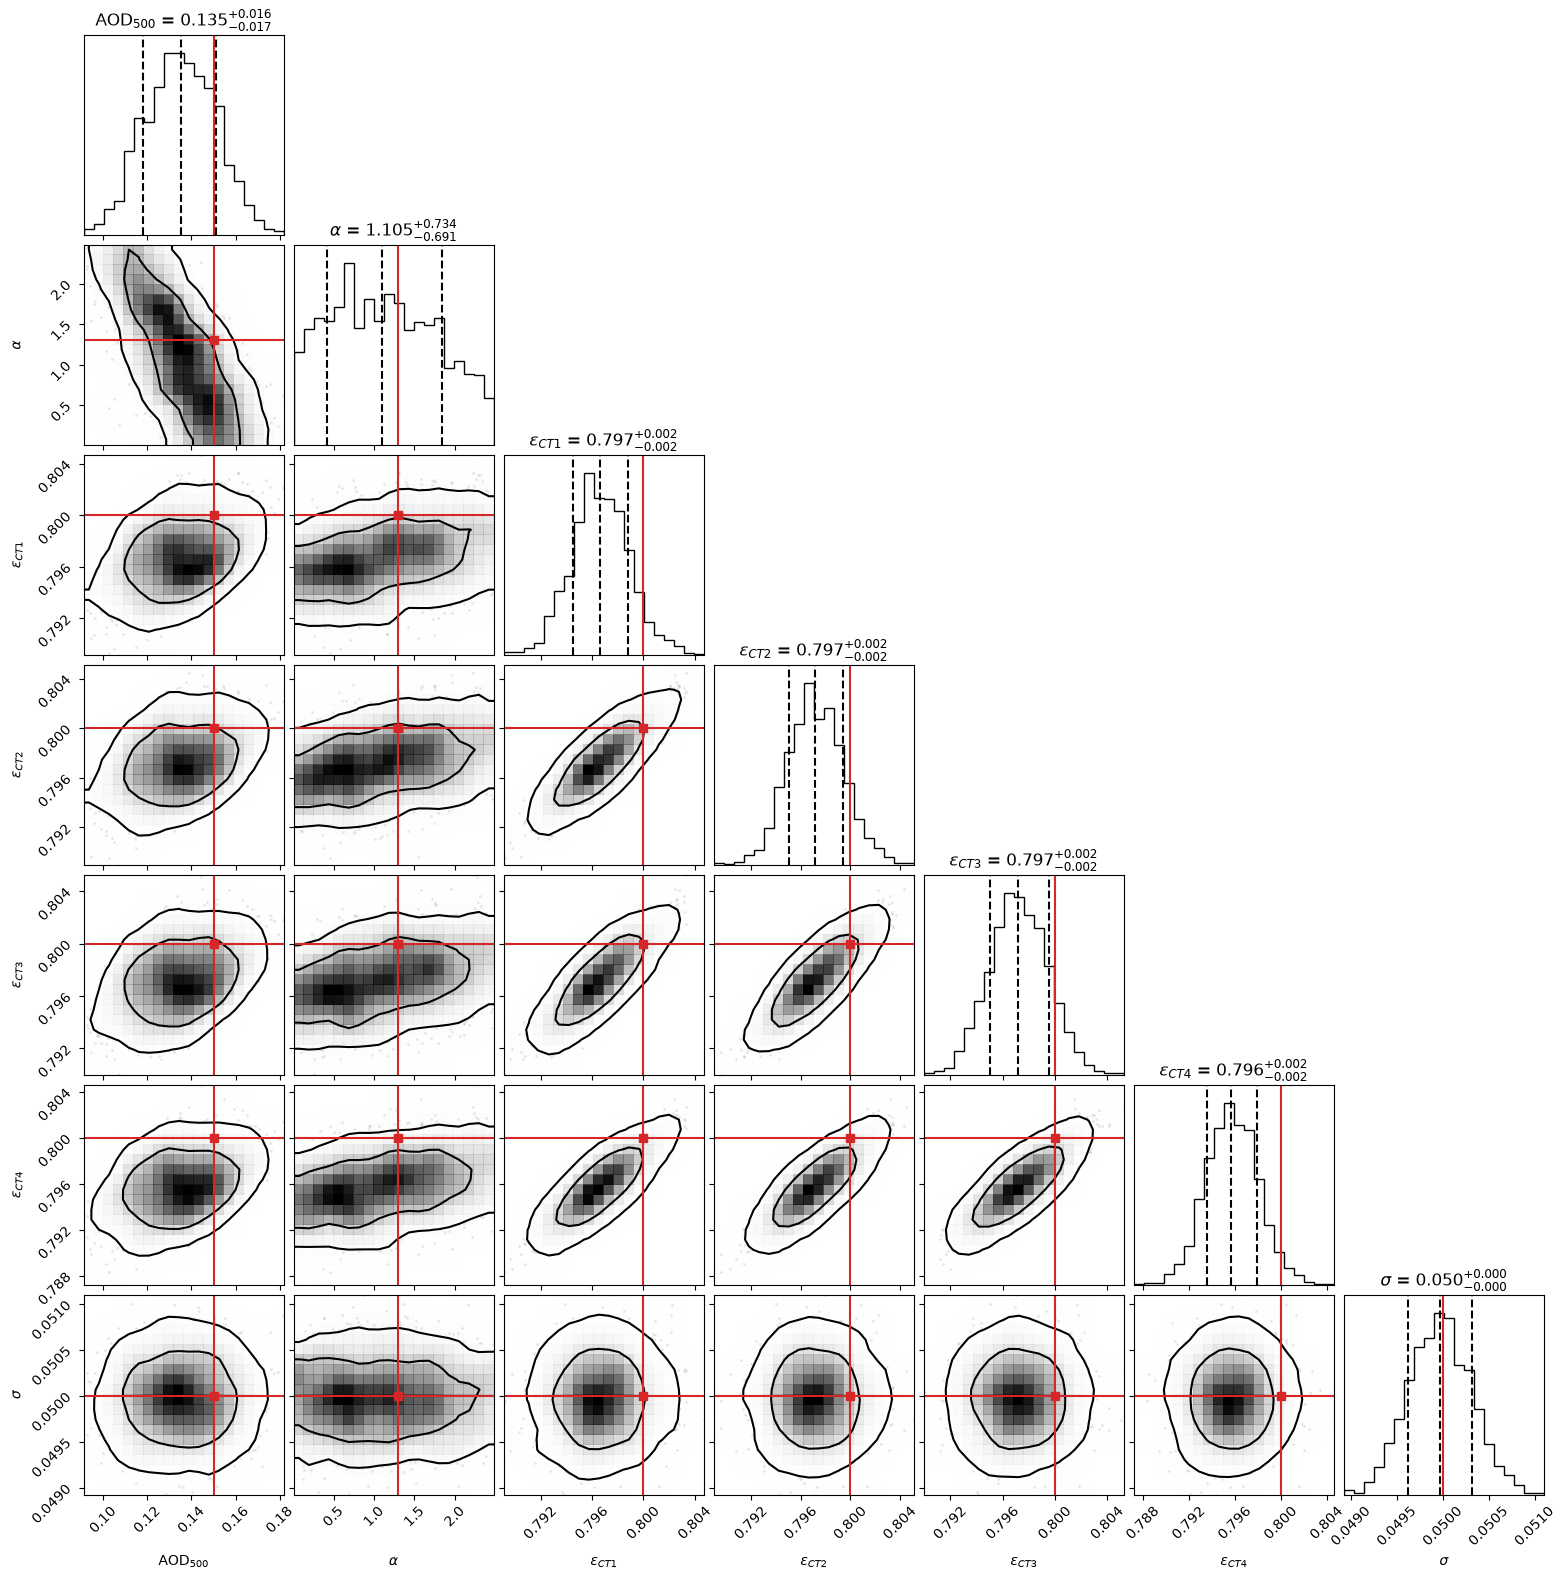

In [18]:
import corner
import matplotlib.pyplot as plt

params = {
    "atmosphere.components.Mie.aod_500": ("AOD$_{500}$", 0.15),
    "atmosphere.components.Mie.angstrom_exp": (r"$\alpha$", 1.3),
    **{f"instruments.{n}.efficiency": (rf"$\epsilon_{{{n}}}$", 0.8) for n in scene},
    "rel_error": (r"$\sigma$", rel_error),
}
data = np.column_stack([np.asarray(samples[k]) for k in params])
labels = [v[0] for v in params.values()]
truths = [v[1] for v in params.values()]

fig = corner.corner(
    data,
    labels=labels,
    truths=truths,
    truth_color="C3",
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    smooth=1.0,
    levels=(0.68, 0.95),
)
plt.show()

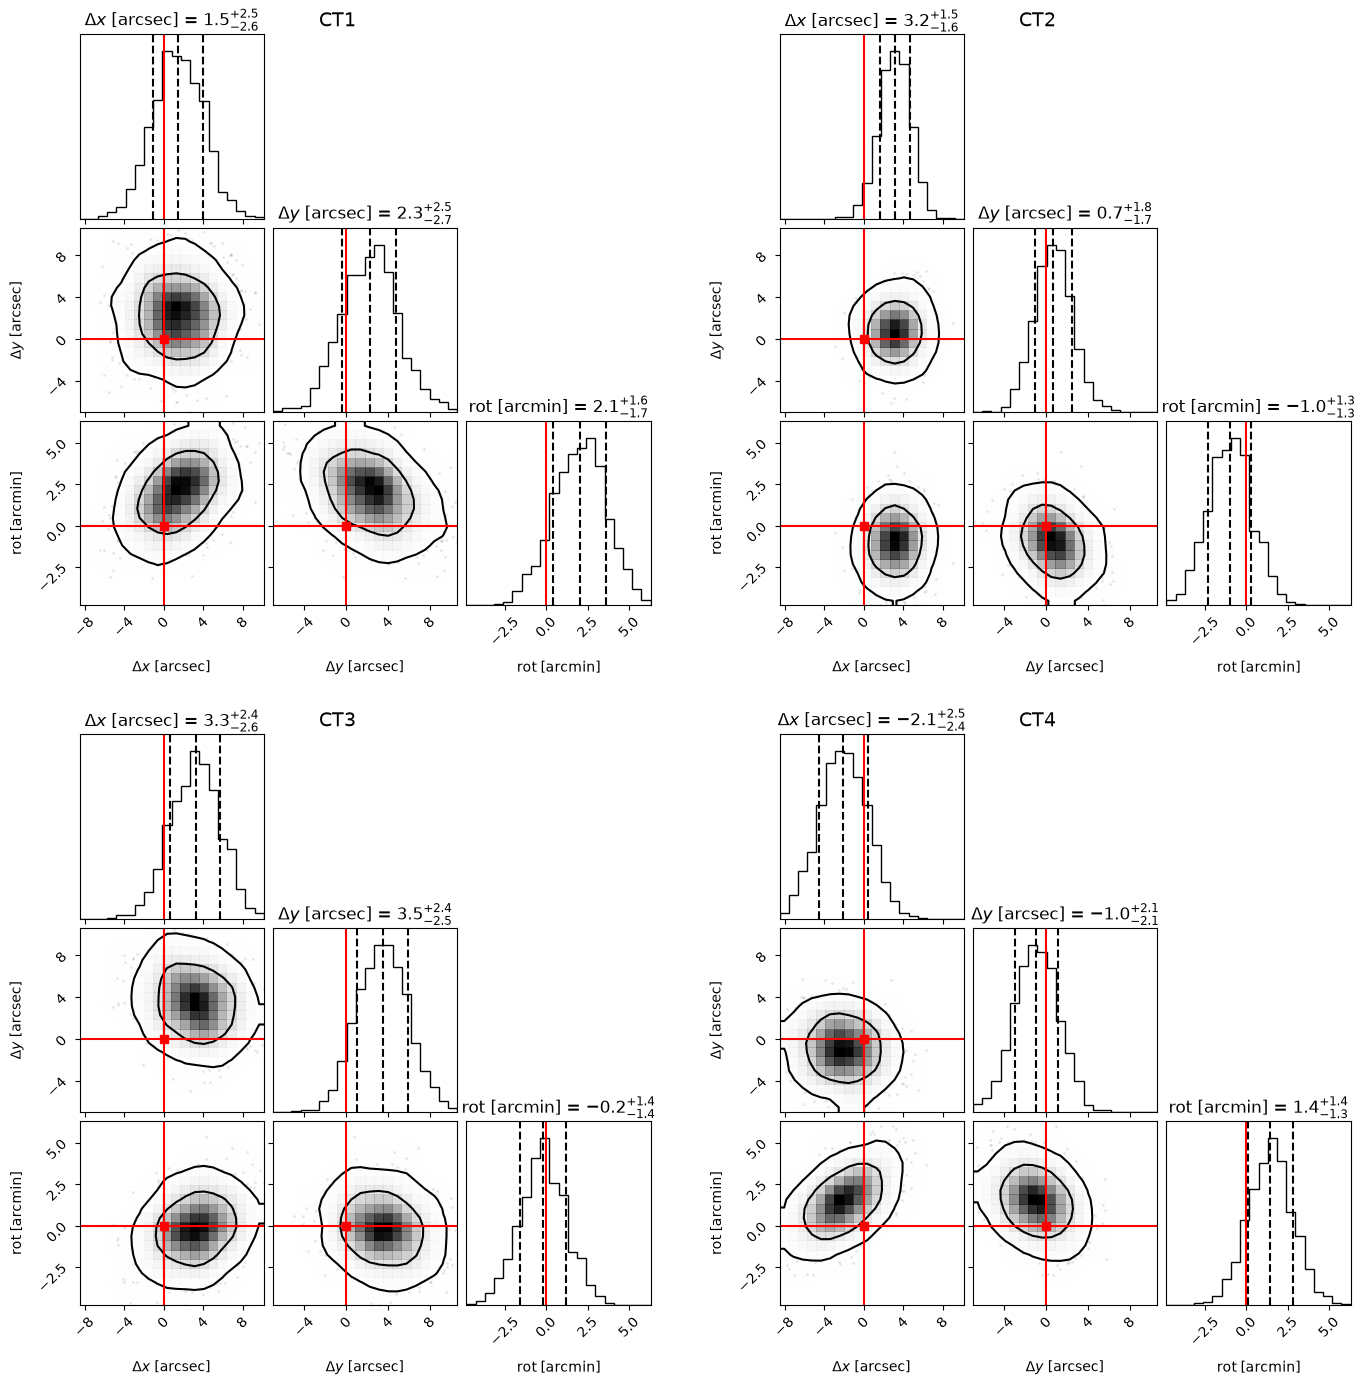

In [20]:
t = 2  # time index
names = list(scene)
colors = [f"C{i}" for i in range(len(names))]
labels = [r"$\Delta x$ [arcsec]", r"$\Delta y$ [arcsec]", "rot [arcmin]"]


def timestep_data(name, t):
    shift = np.asarray(samples[f"instruments.{name}.shift"])
    rot = np.asarray(samples[f"instruments.{name}.rotation"])
    n, nobs = shift.shape[0], scene.nobs[name]
    shift = shift.reshape(n, nobs, 2)[:, t]
    rot = rot.reshape(n, nobs, -1)[:, t, 0]
    dshift = np.rad2deg(shift - true_shifts[name][t]) * 3600
    return np.column_stack([dshift, np.rad2deg(rot) * 60])


data = {name: timestep_data(name, t) for name in names}
allv = np.concatenate(list(data.values()))
lo, hi = np.percentile(allv, [0.5, 99.5], axis=0)
pad = 0.1 * (hi - lo)
ranges = list(zip(lo - pad, hi + pad, strict=False))

fig = plt.figure(figsize=(14, 14))
subfigs = fig.subfigures(2, 2)

for sf, name, _c in zip(subfigs.flat, names, colors, strict=False):
    corner.corner(
        data[name],
        fig=sf,
        color="black",
        labels=labels,
        range=ranges,
        truths=[0.0, 0.0, 0.0],
        truth_color="red",
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt=".1f",
        smooth=1.0,
        levels=(0.68, 0.95),
    )
    sf.suptitle(name, fontsize=14)